This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.

Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []
k_values = list(range(1,11))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss_table = pd.DataFrame({
    "Number of Clusters (K)": k_values,
    "WCSS Value": wcss
})

print(wcss_table)

   Number of Clusters (K)  WCSS Value
0                       1  400.000000
1                       2  273.668887
2                       3  157.704008
3                       4  109.228227
4                       5   65.568408
5                       6   60.132875
6                       7   49.668245
7                       8   37.319123
8                       9   32.495081
9                      10   30.059323


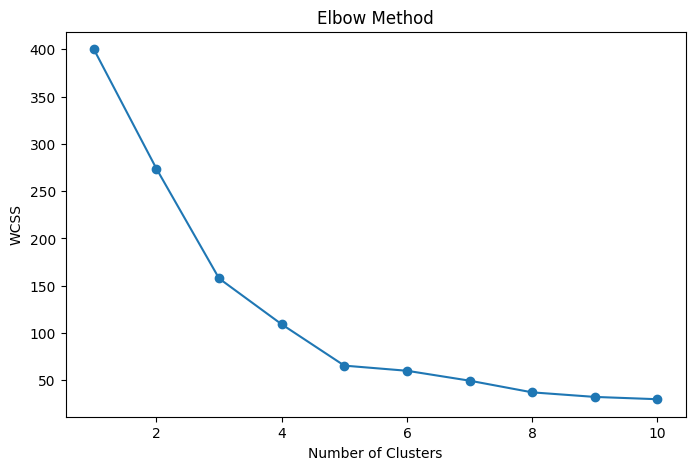

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
sil_scores = []
k_range = list(range(2,11))

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

sil_table = pd.DataFrame({
    "Number of Clusters (K)": k_range,
    "Silhouette Score": sil_scores
})

print(sil_table)

   Number of Clusters (K)  Silhouette Score
0                       2          0.397327
1                       3          0.466585
2                       4          0.494350
3                       5          0.554657
4                       6          0.513826
5                       7          0.502001
6                       8          0.455011
7                       9          0.456662
8                      10          0.444760


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

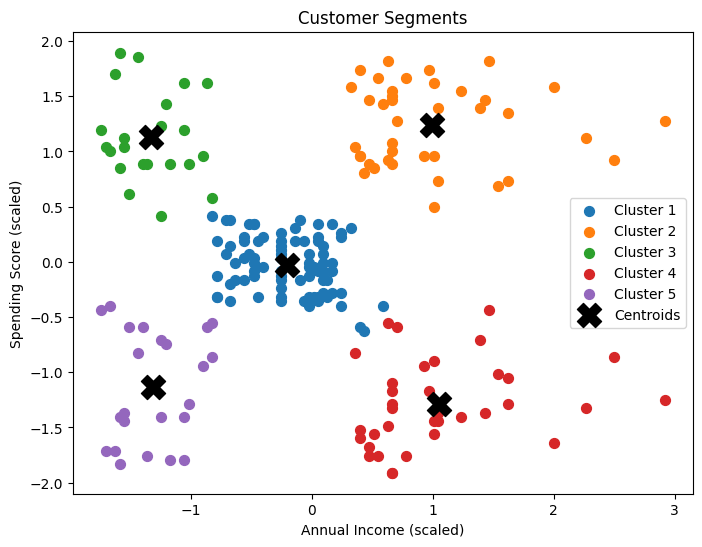

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[y_pred==0,0], X_scaled[y_pred==0,1], s=50, label="Cluster 1")
plt.scatter(X_scaled[y_pred==1,0], X_scaled[y_pred==1,1], s=50, label="Cluster 2")
plt.scatter(X_scaled[y_pred==2,0], X_scaled[y_pred==2,1], s=50, label="Cluster 3")
plt.scatter(X_scaled[y_pred==3,0], X_scaled[y_pred==3,1], s=50, label="Cluster 4")
plt.scatter(X_scaled[y_pred==4,0], X_scaled[y_pred==4,1], s=50, label="Cluster 5")

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=300, c='black', marker='X', label="Centroids")

plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()